In [3]:
# import some regular packages
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import pyproj

# import package that helps with retrieving data from usgs stream gauges
import dataretrieval.nwis as nwis

In [31]:
# nwis.get_record() pulled from AI. Adapted to be a callable function by me.
# all inputs are strings

def usgs_discharge(station, start_date, end_date):
    df = nwis.get_record(
        sites=station, # station ID 
        service="dv", # daily values
        start=start_date, # YYYY-MM-DD
        end=end_date, # YYYY-MM-DD
        parameterCd="00060") # pulls discharge data
    df['Q_cms'] = df['00060_Mean'] * 0.028316847 # convert discharge from cfs to cubic meters per second
    return df

#### Identify station IDs we would like to pull:

https://waterdata.usgs.gov/state/washington/ 

- Elwha River at Mcdonald BR Near Port Angeles, WA - USGS-12045500
- Duckabush River Near Brinnon, WA - USGS-12054000
- NF Skokomish R BL Staircase Rpds NR Hoodsport, WA - USGS-12056500
- Quinault River at Quinault Lake, WA - USGS-12039500
- Bogachiel River Near Forks, WA - USGS-12042800
- Hoh River at US Highway 101 Near Forks, WA - USGS-12041200
- Queets River Near Clearwater, WA - USGS-12040500
- Calawah River Near Forks, WA - USGS-12043000
- Dungeness River Near Sequim, WA - USGS-12048000
- Maybe identify more...

In [64]:
# create a data frame with station ID and names for selected rivers
stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000] # this column is called "0". how to fix?
stations_df = pd.DataFrame(stations, columns=['station_id'])
stations_df.index = ['Elwha River', 'Duckabush River', 'NF Skokomish River', 'Quinalt River', 'Bogachiel River', 'Hoh River',
                    'Queets River', 'Calawah River', 'Dungeness River']

In [81]:
# define start data and end date for all data frames:
start_date = "2020-05-01" # temporary
end_date = "2020-10-30" # temporary

In [82]:
# generate data frames calling station ID and dates
elwha_df = usgs_discharge(f"{stations_df.loc['Elwha River', 'station_id']}", start_date, end_date)

In [83]:
# function to plot a time series of the selected data frames (individual plot):
def discharge_timeseries(df, station):
    fig, ax = plt.subplots()
    df['Q_cms'].plot(ax=ax)
    ax.set_xlabel('Date')
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_title(f"{station} Discharge Time Series")

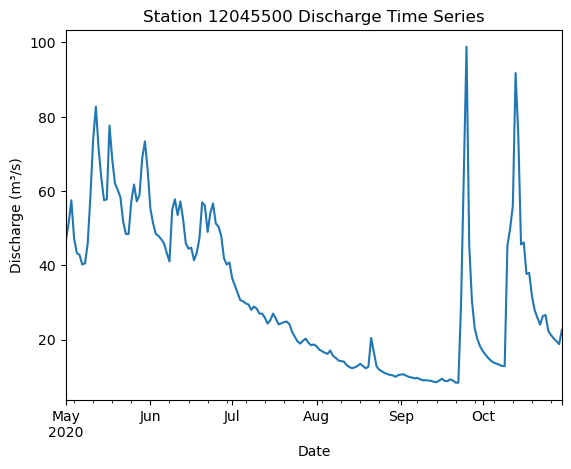

In [84]:
discharge_timeseries(elwha_df, f"Station {stations_df.loc['Elwha River', 'station_id']}")

In [91]:
# %matplotlib widget
%matplotlib inline

Text(0.5, 0, 'Date')

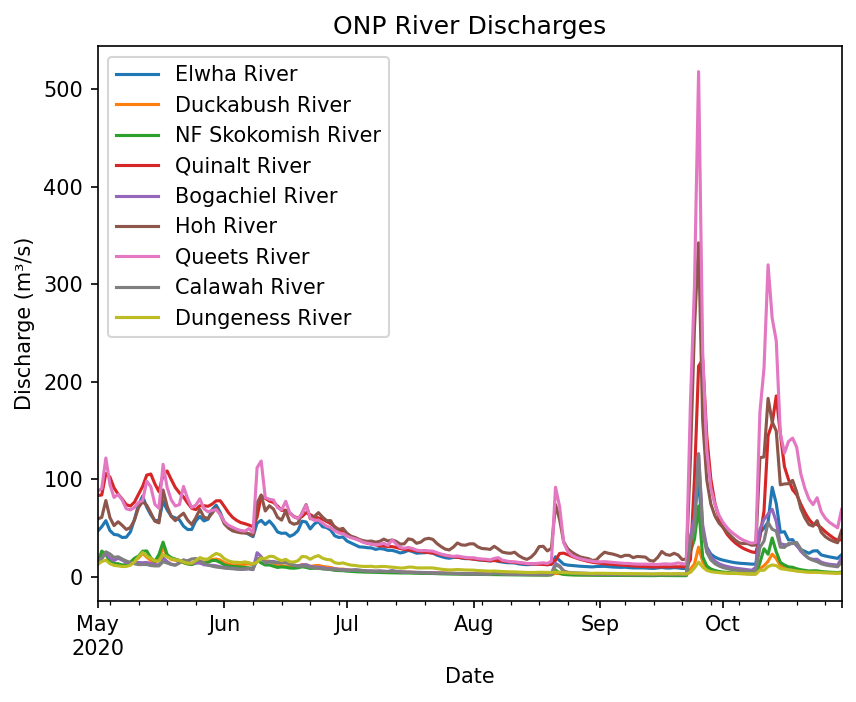

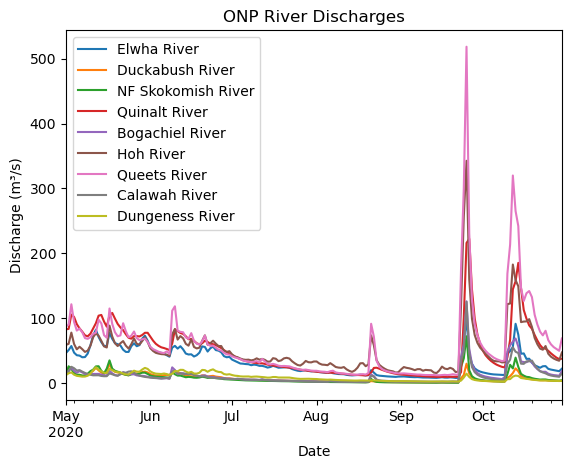

In [92]:
# plot all time series on the same plot
# use this plot to identify high and low seasons

fig, ax = plt.subplots()
ax.set_title(f"ONP River Discharges")
ax.set_ylabel('Discharge (m³/s)')
for river in stations_df.index:
    station_id = stations_df.loc[river, 'station_id']
    df = usgs_discharge(str(station_id), start_date, end_date)
    df['Q_cms'].plot(ax=ax, label=river)  
ax.legend()
ax.set_xlabel('Date')